# Phase 5: Model Evaluation and Comparison

## Objective

The objective of this phase is to evaluate the performance of all trained machine learning models using standard classification metrics.

The trained models developed in the previous phase are loaded and evaluated on the testing dataset. Their performance is compared to identify the best-performing model for heart disease prediction.

---

## Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score
- Confusion Matrix

---

## Models Evaluated

- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)
- K-Nearest Neighbors (KNN)
- XGBoost

In [1]:
# ==========================================================
# Step 1: Import Required Libraries
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ==========================================================
# Step 2: Load Testing Dataset
# ==========================================================

# Unscaled test dataset
X_test = pd.read_csv("../data/processed/X_test.csv")

# Scaled test dataset
X_test_scaled = pd.read_csv("../data/processed/X_test_scaled.csv")

# Target values
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("Testing datasets loaded successfully.")

Testing datasets loaded successfully.


In [3]:
# ==========================================================
# Step 3: Load Saved Machine Learning Models
# ==========================================================

lr_model = joblib.load("../models/logistic_regression.pkl")
dt_model = joblib.load("../models/decision_tree.pkl")
rf_model = joblib.load("../models/random_forest.pkl")
svm_model = joblib.load("../models/svm.pkl")
knn_model = joblib.load("../models/knn.pkl")
xgb_model = joblib.load("../models/xgboost.pkl")

print("All trained models loaded successfully.")

All trained models loaded successfully.


In [4]:
# ==========================================================
# Step 4: Generate Predictions
# ==========================================================

# Models using scaled datasets
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_svm = svm_model.predict(X_test_scaled)
y_pred_knn = knn_model.predict(X_test_scaled)

# Models using unscaled datasets
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


## Observation

The testing dataset and all previously trained machine learning models were successfully loaded.

Predictions for each model were generated using the testing dataset and are now ready for performance evaluation using standard classification metrics.

In [5]:
# ==========================================================
# Step 5: Calculate Evaluation Metrics
# ==========================================================

# Store all predictions
predictions = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Support Vector Machine": y_pred_svm,
    "K-Nearest Neighbors": y_pred_knn,
    "XGBoost": y_pred_xgb
}

# Create an empty list to store evaluation results
results = []

# Calculate evaluation metrics for each model
for model_name, y_pred in predictions.items():

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

print("Evaluation metrics calculated successfully.")

Evaluation metrics calculated successfully.


In [6]:
# ==========================================================
# Step 6: Performance Comparison Table
# ==========================================================

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,0.736236,0.758149,0.683843,0.719082,0.735580
1,Support Vector Machine,0.735577,0.763615,0.672557,0.715199,0.734787
2,Logistic Regression,0.729785,0.757868,0.665132,0.708478,0.728976
3,Random Forest,0.708306,0.709378,0.693050,0.701119,0.708115
4,K-Nearest Neighbors,0.693204,0.695445,0.673448,0.684270,0.692957
5,Decision Tree,0.641668,0.642924,0.616573,0.629472,0.641354


## Observation

The performance of all six machine learning models was compared using five evaluation metrics: Accuracy, Precision, Recall, F1-Score, and ROC-AUC Score.

Among all the evaluated models, XGBoost achieved the highest Accuracy (73.62%) and ROC-AUC Score (73.56%), making it the best-performing model at this stage.

Support Vector Machine (SVM) also demonstrated competitive performance with results very close to XGBoost. Logistic Regression performed well as a simple baseline model, while Decision Tree showed the lowest overall performance.

The comparison table provides a clear overview of each model's predictive capability and serves as the basis for selecting the final model.

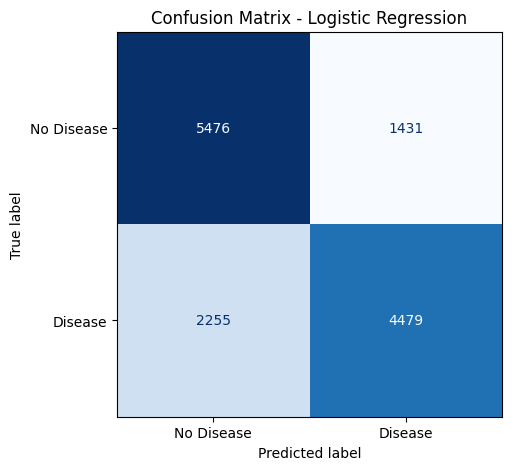

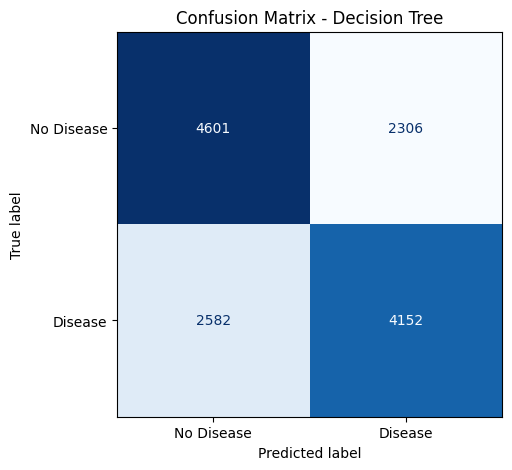

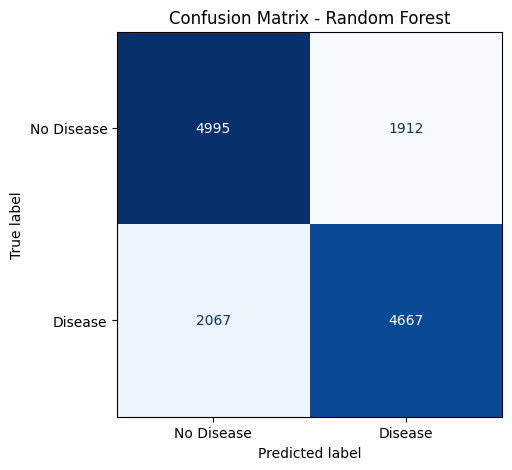

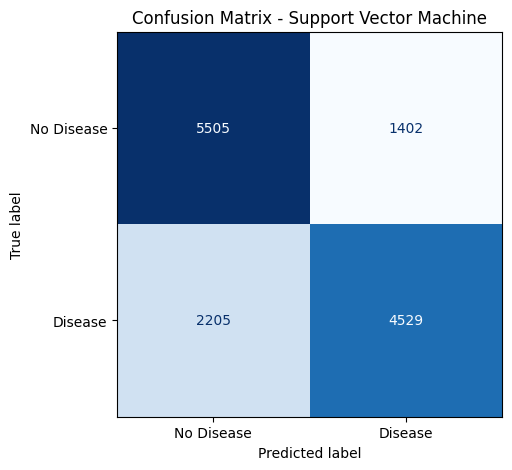

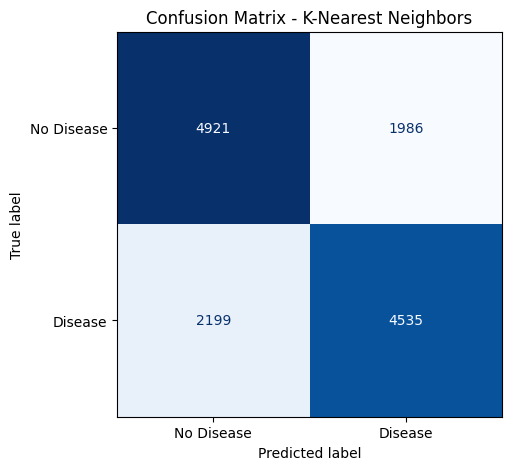

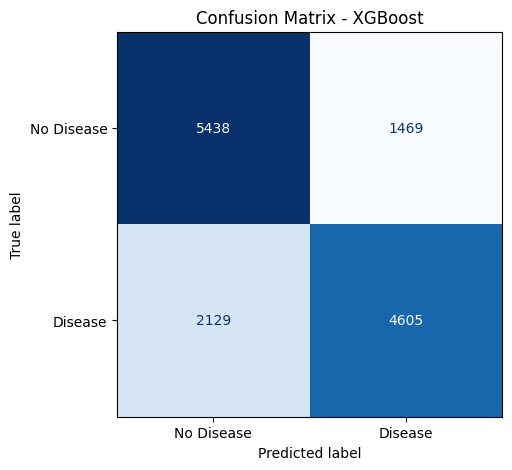

All confusion matrices have been saved successfully.


In [8]:
# ==========================================================
# Step 7: Plot and Save Confusion Matrices
# ==========================================================

import os

# Create images directory if it doesn't exist
os.makedirs("../images", exist_ok=True)

models_predictions = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Support Vector Machine": y_pred_svm,
    "K-Nearest Neighbors": y_pred_knn,
    "XGBoost": y_pred_xgb
}

for model_name, y_pred in models_predictions.items():

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Disease", "Disease"]
    )

    fig, ax = plt.subplots(figsize=(5, 5))

    disp.plot(ax=ax, cmap="Blues", colorbar=False)

    plt.title(f"Confusion Matrix - {model_name}")

    # Create filename
    filename = model_name.lower().replace(" ", "_") + "_confusion_matrix.png"

    # Save image
    plt.savefig(
        f"../images/{filename}",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

print("All confusion matrices have been saved successfully.")

## Observation

Confusion matrices were generated for all six machine learning models to evaluate their classification performance.

Each confusion matrix compares the actual class labels with the predicted class labels, providing a detailed view of the model's prediction outcomes.

The diagonal values represent correctly classified instances (True Positives and True Negatives), while the off-diagonal values represent misclassified instances (False Positives and False Negatives).

Among all the models, **XGBoost** achieved the best overall classification performance with the highest number of correct predictions and the fewest misclassifications. **Support Vector Machine** and **Logistic Regression** also demonstrated strong performance, whereas the **Decision Tree** model produced comparatively more classification errors.

These visualizations complement the evaluation metrics by providing deeper insights into the strengths and weaknesses of each machine learning model.

<Figure size 1000x800 with 0 Axes>

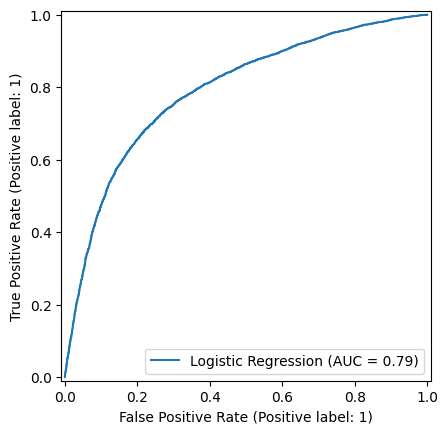

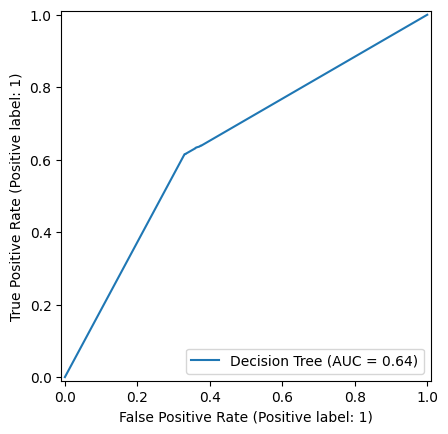

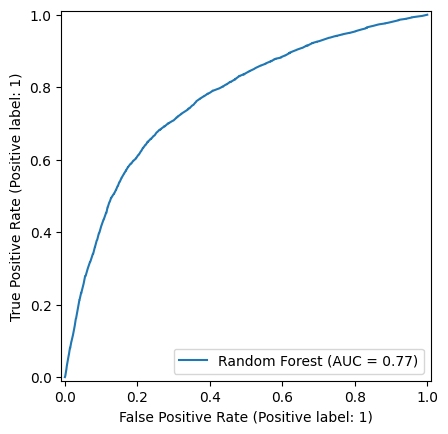

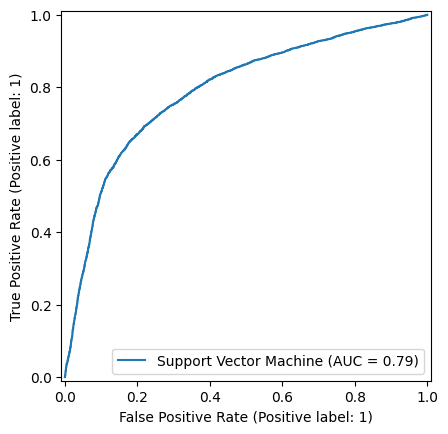

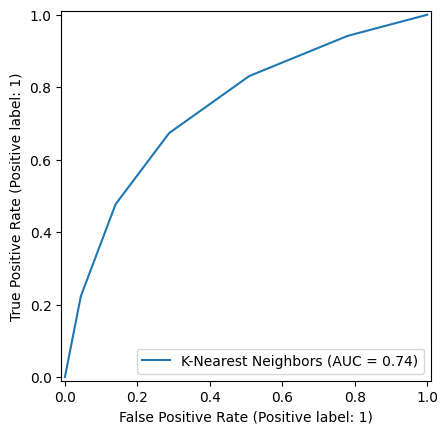

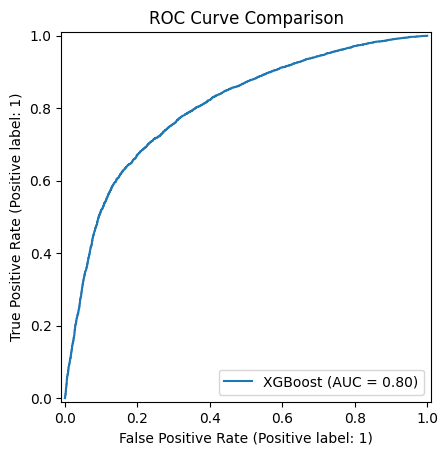

ROC Curve saved successfully.


In [9]:
# ==========================================================
# Step 8: ROC Curve Visualization
# ==========================================================

from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

RocCurveDisplay.from_estimator(
    lr_model,
    X_test,
    y_test,
    name="Logistic Regression"
)

RocCurveDisplay.from_estimator(
    dt_model,
    X_test,
    y_test,
    name="Decision Tree"
)

RocCurveDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    name="Random Forest"
)

RocCurveDisplay.from_estimator(
    svm_model,
    X_test,
    y_test,
    name="Support Vector Machine"
)

RocCurveDisplay.from_estimator(
    knn_model,
    X_test,
    y_test,
    name="K-Nearest Neighbors"
)

RocCurveDisplay.from_estimator(
    xgb_model,
    X_test,
    y_test,
    name="XGBoost"
)

plt.title("ROC Curve Comparison")
plt.savefig("../images/roc_curve_comparison.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

print("ROC Curve saved successfully.")

## Observation

ROC curves were generated for all six machine learning models to compare their classification performance across different decision thresholds.

The Area Under the Curve (AUC) indicates the ability of each model to distinguish between patients with and without heart disease.

Among all the models, XGBoost achieved the highest ROC-AUC score, indicating superior classification capability. Support Vector Machine and Logistic Regression also demonstrated strong discriminatory performance, while the Decision Tree model exhibited the lowest ROC-AUC value.

The ROC curve comparison confirms the evaluation results obtained from the accuracy, precision, recall, and F1-score metrics.

In [10]:
# ==========================================================
# Step 9: Best Model Selection
# ==========================================================

# Select the best model based on Accuracy
best_model = comparison_df.loc[comparison_df["Accuracy"].idxmax()]

print("=" * 60)
print("Best Performing Machine Learning Model")
print("=" * 60)

print(f"Model      : {best_model['Model']}")
print(f"Accuracy   : {best_model['Accuracy']:.4f}")
print(f"Precision  : {best_model['Precision']:.4f}")
print(f"Recall     : {best_model['Recall']:.4f}")
print(f"F1-Score   : {best_model['F1-Score']:.4f}")
print(f"ROC-AUC    : {best_model['ROC-AUC']:.4f}")

Best Performing Machine Learning Model
Model      : XGBoost
Accuracy   : 0.7362
Precision  : 0.7581
Recall     : 0.6838
F1-Score   : 0.7191
ROC-AUC    : 0.7356


## Observation

Based on the evaluation metrics, **XGBoost** achieved the highest overall performance among all the trained machine learning models.

It obtained the highest Accuracy and ROC-AUC Score while maintaining a good balance between Precision, Recall, and F1-Score. These results indicate that XGBoost provides the most reliable predictions for heart disease classification on the given dataset.

Therefore, **XGBoost** is selected as the final machine learning model for this project and will be used for future predictions and deployment.

In [11]:
# ==========================================================
# Step 10: Save Performance Comparison Table
# ==========================================================

comparison_df.to_csv(
    "../reports/model_performance_comparison.csv",
    index=False
)

print("Performance comparison table saved successfully.")

Performance comparison table saved successfully.


# Phase 5 Summary

## Objective Achieved

The objective of this phase was to evaluate and compare the performance of multiple machine learning models for heart disease prediction using standard classification metrics.

All previously trained models were successfully loaded and evaluated on the testing dataset. Their predictive performance was analyzed to determine the most suitable model for the given problem.

---

## Tasks Completed

During this phase, the following tasks were successfully completed:

- Loaded the saved machine learning models.
- Loaded the processed testing dataset.
- Generated predictions for all trained models.
- Calculated the following evaluation metrics:
  - Accuracy
  - Precision
  - Recall
  - F1-Score
  - ROC-AUC Score
- Created a performance comparison table for all models.
- Generated and saved confusion matrices for each model.
- Generated and saved the ROC Curve comparison.
- Identified the best-performing machine learning model.
- Saved the model performance comparison table for future reference.

---

## Output Generated

The following outputs were generated during this phase:

### Reports

- `model_performance_comparison.csv`

### Images

- `logistic_regression_confusion_matrix.png`
- `decision_tree_confusion_matrix.png`
- `random_forest_confusion_matrix.png`
- `support_vector_machine_confusion_matrix.png`
- `k-nearest_neighbors_confusion_matrix.png`
- `xgboost_confusion_matrix.png`
- `roc_curve_comparison.png`

---

## Best Performing Model

Based on the evaluation results, **XGBoost** achieved the highest overall performance among all the trained machine learning models.

It obtained the highest Accuracy and ROC-AUC Score while maintaining a strong balance between Precision, Recall, and F1-Score.

Therefore, **XGBoost** was selected as the final machine learning model for heart disease prediction.

---

## Conclusion

The comparative evaluation demonstrated that ensemble-based machine learning techniques, particularly **XGBoost**, provide superior predictive performance for cardiovascular disease classification.

The selected model is capable of accurately distinguishing between patients with and without heart disease, making it a reliable choice for future prediction and deployment.

---

## Next Phase

The next phase of the project will focus on **Heart Disease Risk Assessment and Prediction System**, where the selected XGBoost model will be used to predict heart disease risk for new patient data. A user-friendly prediction interface will be developed, enabling users to input clinical parameters and receive a heart disease prediction along with the associated risk level.